# Random Forest with Full Preprocessing Pipeline

Trains a Random Forest inside the pipeline described in §2.2:

```
Pipeline([
    ('mice_imputer',   MiceForestImputer),   # miceforest imputation (RF-based)
    ('knn_imputer',    KNNImputer),          # safety net for fully-missing cols
    ('scaler',         StandardScaler | MinMaxScaler | 'passthrough'),
    ('selection',      SelectKBest(k)),
    ('quasi_constant', VarianceThreshold | 'passthrough'),
    ('model',          RandomForestClassifier)
])
```

**Single fixed hyperparameter set** is passed as a dictionary – no Optuna, no tuning.

Evaluation protocol:
1. Hold out a stratified test set (20 %).
2. Run **5-fold stratified CV** on the remaining 80 % → **cross-validation performance**.
3. Fit the pipeline on the full 80 % training portion, evaluate on the 20 % test set → **test-set performance**.

Reported metrics: **F1, AUC-ROC, Precision, Recall**.

## 1. Imports

In [1]:
# If needed:
# !pip install miceforest scikit-learn pandas numpy

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score
)

import miceforest as mf
import os 
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Custom `miceforest` transformer

`miceforest` isn't a scikit-learn transformer out of the box, so we wrap it.
Crucially, `fit` is called only on the training fold/portion – this is what prevents data leakage when the transformer sits inside a `Pipeline` used for cross-validation.

In [2]:
class MiceForestImputer(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible wrapper around miceforest.ImputationKernel.

    Parameters
    ----------
    iterations : int, default=3
        Number of MICE iterations (1..5 as per study).
    initialization : {'random', 'empty'}, default='random'
        How missing values are initialized before MICE iterations.
    random_state : int, default=42
    """

    def __init__(self, iterations=3, initialization='random', random_state=RANDOM_STATE):
        self.iterations = iterations
        self.initialization = initialization
        self.random_state = random_state

    def _to_frame(self, X):
        if isinstance(X, pd.DataFrame):
            df = X.copy()
        else:
            cols = [f"f{i}" for i in range(X.shape[1])]
            df = pd.DataFrame(X, columns=cols)
        # miceforest requires a clean integer index and string column names
        df = df.reset_index(drop=True)
        df.columns = [str(c) for c in df.columns]
        return df

    def fit(self, X, y=None):
        X_df = self._to_frame(X)
        self.feature_names_in_ = list(X_df.columns)

        # miceforest v6 API – 'empty' vs 'random' is controlled by initialize_empty.
        initialize_empty = (self.initialization == 'empty')

        self.kernel_ = mf.ImputationKernel(
            data=X_df,
            num_datasets=1,
            initialize_empty=initialize_empty,
            random_state=self.random_state,
        )
        self.kernel_.mice(self.iterations)
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        # Align columns with training set
        X_df = X_df.reindex(columns=self.feature_names_in_)

        if not X_df.isnull().values.any():
            return X_df.values

        imputed_kernel = self.kernel_.impute_new_data(X_df)
        imputed_df = imputed_kernel.complete_data(dataset=0)
        return imputed_df.values

## 3. Pipeline builder

All settings come from a single dictionary:

| key | options |
|---|---|
| `mice_init` | `'random'`, `'empty'` |
| `mice_iter` | integer 1..5 |
| `scaler` | `'StandardScaler'`, `'MinMaxScaler'`, `'passthrough'` |
| `quasi_constant` | `'variance_threshold'`, `'passthrough'` |
| `quasi_constant__threshold` | float 0.0..0.15 (only if VT is used) |
| `selection_kbest_features` | integer 5..30 |
| `rf_params` | dict forwarded to `RandomForestClassifier` |

In [3]:
def build_pipeline(params: dict) -> Pipeline:
    """Build the full preprocessing + RF pipeline from a params dict."""

    # --- 2.2.1 imputation ---------------------------------------------------
    mice_imputer = MiceForestImputer(
        iterations=params.get('mice_iter', 3),
        initialization=params.get('mice_init', 'random'),
        random_state=RANDOM_STATE,
    )

    # Safety net: some features may have zero missing in train but missing in
    # test, or vice-versa. KNN fills anything MICE may have left over.
    knn_imputer = KNNImputer(n_neighbors=5)

    # --- 2.2.2 scaling ------------------------------------------------------
    scaler_name = params.get('scaler', 'passthrough')
    if scaler_name == 'StandardScaler':
        scaler = StandardScaler()
    elif scaler_name == 'MinMaxScaler':
        scaler = MinMaxScaler()
    elif scaler_name == 'passthrough':
        scaler = 'passthrough'
    else:
        raise ValueError(f"Unknown scaler: {scaler_name}")

    # --- 2.2.5 feature selection -------------------------------------------
    k = int(params.get('selection_kbest_features', 15))
    if not (5 <= k <= 30):
        raise ValueError('selection_kbest_features must be in [5, 30]')
    selection = SelectKBest(score_func=f_classif, k=k)

    # --- 2.2.3 quasi-constant features -------------------------------------
    qc = params.get('quasi_constant', 'passthrough')
    if qc == 'variance_threshold':
        threshold = params.get('quasi_constant__threshold', 0.0)
        if not (0.0 <= threshold <= 0.15):
            raise ValueError('quasi_constant__threshold must be in [0, 0.15]')
        constant = VarianceThreshold(threshold=threshold)
    elif qc == 'passthrough':
        constant = 'passthrough'
    else:
        raise ValueError(f"Unknown quasi_constant: {qc}")

    # --- model -------------------------------------------------------------
    rf_params = params.get('rf_params', {}).copy()
    rf_params.setdefault('random_state', RANDOM_STATE)
    rf_params.setdefault('n_jobs', -1)
    model = RandomForestClassifier(**rf_params)

    pipe = Pipeline([
        ('mice_imputer',   mice_imputer),
        ('knn_imputer',    knn_imputer),
        ('scaler',         scaler),
        ('selection',      selection),
        ('quasi_constant', constant),
        ('model',          model),
    ])
    return pipe

## 4. Define hyperparameters

Edit this dict to try a different configuration. Then re-run from here.

In [4]:
params = {
    # --- pipeline settings ---
    'mice_init':                  'random', 
    'mice_iter':                  4,   
    'scaler':                     'StandardScaler',
    'quasi_constant':             'passthrough',
    'quasi_constant__threshold':  0.01,            # 0..0.15
    'selection_kbest_features':   18,              # 5..30

    # --- random forest hyperparameters ---
    'rf_params': {
        'n_estimators':      328,
        'max_depth':         1,
        'min_samples_split': 2,
        'min_samples_leaf':  1,
        'max_features':      'sqrt',
        'class_weight':      'balanced',
        'random_state':      RANDOM_STATE,
        'n_jobs':            -1,
    },
}

## 5. Load data

In [28]:
# define directories 
work_dir = os.path.dirname(os.getcwd()) 
data_dir = os.path.join(work_dir, "data")
out_dir = os.path.join(work_dir, "results")
os.makedirs(out_dir, exist_ok=True)

# Print paths for verification
print(f"Working directory: {work_dir}")
print(f"Data directory: {data_dir}")
print(f"Output directory: {out_dir}")


Working directory: /Users/dzhakparov/Documents/Projects/SOS-ALL_Revision
Data directory: /Users/dzhakparov/Documents/Projects/SOS-ALL_Revision/data
Output directory: /Users/dzhakparov/Documents/Projects/SOS-ALL_Revision/results


In [29]:
# define the data files 
data = pd.read_csv(os.path.join(data_dir, "DataTransformed_ImmunoCAP_Final.txt"), sep='\t')  
include_cols = pd.read_csv(os.path.join(data_dir, "DataTransformed_ImmunoCAP_Final_value_report_f_dtypes_original.csv"), sep=';') 

In [30]:
# inspect dataframes 
print("Data head:")
print(data.head())
print("\nInclude_cols head:")
print(include_cols.head())


Data head:
   Unnamed: 0        PID diagnosis location  enrolment_age  gender  \
0           0  CA-001-LS        AD    Urban             24     2.0   
1           1  CA-002-YF        AD    Urban             14     1.0   
2           2  CA-003-US        AD    Urban             20     2.0   
3           3  CA-004-NK        AD    Urban             14     1.0   
4           4  CA-005-BD        AD    Urban             17     2.0   

   vaccination_status  paracetamol_exposure  paracetamol_exposure_age  \
0                 1.0                   1.0                      11.0   
1                 1.0                   1.0                       8.0   
2                 1.0                   1.0                       4.0   
3                 1.0                   1.0                       1.0   
4                 1.0                   1.0                       6.0   

   paracetamol_exposure_time  ...  fuel_heating_Other  log_blood_counts_wcc  \
0                        1.0  ...                 

In [31]:
include_cols

,Unnamed: 0,variable,value_counts,unique_values,nan_counts,nan_percentage,exclude,dtype,Unnamed: 8
0,0,Unnamed:,0,"{0: 1, 149: 1, 138: 1, 139: 1, 140: 1, 141: 1,...",217,0.000000,0.0,1,NaN
1,1,PID,"{'CA-001-LS': 1, 'CO-035-SM': 1, 'CO-024-KM': ...",217,0,0.000000,0.0,cat,NaN
2,2,diagnosis,"{'AD': 116, 'HC': 101}",2,0,0.000000,0.0,cat,NaN
3,3,location,"{'Rural': 112, 'Urban': 105}",2,0,0.000000,0.0,cat,NaN
4,4,enrolment_age,"{17: 14, 14: 13, 12: 12, 19: 11, 23: 10, 21: 1...",30,0,0.000000,0.0,num,NaN
...,...,...,...,...,...,...,...,...,...
135,135,log_blood_counts_monocytes,"{-0.371063681: 6, -0.356674944: 5, 0.039220713...",115,43,19.815668,0.0,num,NaN
136,136,log_blood_counts_lymphocytes,"{1.373715579: 3, 1.526056303: 3, 1.870262531: ...",148,44,20.276498,0.0,num,NaN
137,137,log_blood_counts_eosinophils,"{-2.302585093: 8, -1.078809661: 5, -1.60943791...",104,41,18.894009,0.0,num,NaN
138,138,diagnosis_location,"{'AD_Rural': 60, 'AD_Urban': 56, 'HC_Rural': 5...",4,0,0.000000,1.0,cat,NaN


In [32]:
# exlude columns that are equal to 1.0 in the "exclude" columns in the include_cols dataframe 
# the name of the columns is stored in the "variable" column 
exclude_cols = include_cols[include_cols['exclude'] == 1.0]['variable'].tolist()
print(f"Excluding {len(exclude_cols)} columns: {exclude_cols}")


# exlude columns from the data dataframe
data = data.drop(columns=exclude_cols)

print(f"Data shape before excluding columns: {data.shape}")
print(f"Data shape after excluding columns: {data.shape}")

# remove the "Unnamed: 0" column if it exists (it may be an artifact of saving/loading)
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")   
    
# remove the 'PID" column
if 'PID' in data.columns:
    data = data.drop(columns=['PID'])
    print("Dropped 'PID' column.")
    
        


Excluding 31 columns: ['vaccination_status', 'antibiotic_exposure_age', 'solidfood_which_first', 'peanuts_exposure_age_first', 'peanuts_exposure_regularity', 'othernuts_exposure_age_first', 'othernuts_exposure_regularity', 'fish_exposure_age_first', 'fish_exposure_regularity', 'eczema_ever', 'eczema_age', 'eczema_whodiagnosed', 'medication_any', 'medication_nasalcorticosteroid', 'medication_antihistamines', 'medication_steroidcreams', 'medication_oral_which', 'medication_antihistamines_last', 'medicalhistory_comorbidities', 'parental_education_level', 'parental_income', 'am_height', 'am_weight', 'am_abd_girth', 'am_skinfold', 'scorad', 'bsa', 'familyhistory_sibling_eczema', 'familyhistory_sibling_other_allergic_disease', 'diagnosis_location', 'RNASeq']
Data shape before excluding columns: (217, 109)
Data shape after excluding columns: (217, 109)
Dropped 'Unnamed: 0' column.
Dropped 'PID' column.


In [33]:
data 

,diagnosis,location,enrolment_age,gender,paracetamol_exposure,paracetamol_exposure_age,paracetamol_exposure_time,childhood_inf_mumps,childhood_inf_chickenpox,childhood_inf_giandular_fever,...,fuel_cooking_heating_Paraffin,fuel_heating_Wood_Coal,fuel_heating_Other,log_blood_counts_wcc,log_blood_counts_hb,log_blood_counts_plts,log_blood_counts_neutrophils,log_blood_counts_monocytes,log_blood_counts_lymphocytes,log_blood_counts_eosinophils
0,AD,Urban,24,2.0,1.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,2.380472,2.442347,6.165628,1.229641,-0.162519,1.477049,0.900161
1,AD,Urban,14,1.0,1.0,8.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.521721,2.433613,6.180224,1.269761,0.292670,1.948763,-0.174353
2,AD,Urban,20,2.0,1.0,4.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.078191,2.388763,4.812997,0.837248,-0.713350,1.526056,-0.210721
3,AD,Urban,14,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.559550,2.572612,5.673667,0.982078,-0.139262,1.968510,0.824175
4,AD,Urban,17,2.0,1.0,6.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,HC,Rural,13,2.0,1.0,3.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,2.218116,2.312535,5.838022,0.647103,0.165514,1.708378,-0.150823
213,HC,Rural,26,1.0,1.0,NaN,NaN,0.0,0.0,0.0,...,1.0,0.0,0.0,1.934416,2.351375,5.403128,0.609766,-0.579818,1.401183,-0.301105
214,HC,Rural,23,1.0,1.0,7.0,2.0,0.0,0.0,0.0,...,0.0,1.0,0.0,2.381396,2.476538,5.835103,0.850151,0.307485,1.937302,-0.820981
215,HC,Rural,26,1.0,1.0,9.0,2.0,0.0,0.0,0.0,...,1.0,0.0,0.0,2.336987,2.360854,5.549465,1.278152,0.058269,1.633154,-0.198451


## 6. Train / test split

In [41]:
# define X and y 
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# encode y as integers (0, 1, 2)
y = y.astype('category').cat.codes


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape}, class counts: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test : {X_test.shape}, class counts: {pd.Series(y_test).value_counts().to_dict()}")

Train: (173, 106), class counts: {0: 92, 1: 81}
Test : (44, 106), class counts: {0: 24, 1: 20}


## 7. Metric helper

In [55]:
def compute_metrics(y_true, y_pred, y_proba):
    return {
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_true, y_proba),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
    }

## 8. 5-fold cross-validation on training data

A **fresh pipeline is cloned for every fold** – this guarantees that MICE, scaling, feature selection, etc. are all re-fit from scratch on each training split (no state leakage).

In [44]:
def run_cv(X_tr, y_tr, params, n_splits=5, random_state=RANDOM_STATE, verbose=True):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    y_arr = np.asarray(y_tr)
    X_is_df = isinstance(X_tr, pd.DataFrame)

    fold_metrics = []
    for k, (itr, iva) in enumerate(cv.split(X_tr, y_arr), start=1):
        X_itr = X_tr.iloc[itr] if X_is_df else X_tr[itr]
        X_iva = X_tr.iloc[iva] if X_is_df else X_tr[iva]
        y_itr, y_iva = y_arr[itr], y_arr[iva]

        pipe = build_pipeline(params)
        pipe.fit(X_itr, y_itr)
        y_pred  = pipe.predict(X_iva)
        y_proba = pipe.predict_proba(X_iva)[:, 1]
        m = compute_metrics(y_iva, y_pred, y_proba)
        m['fold'] = k
        fold_metrics.append(m)

        if verbose:
            print(f"[Fold {k}] f1={m['f1']:.3f}  auc={m['auc_roc']:.3f}  "
                  f"prec={m['precision']:.3f}  rec={m['recall']:.3f}")

    return fold_metrics


cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

for col in cat_cols:
    cats = pd.Categorical(pd.concat([X_train_enc[col], X_test_enc[col]], ignore_index=True)).categories
    for col in cat_cols:
        cats = pd.Categorical(pd.concat([X_train_enc[col], X_test_enc[col]], ignore_index=True)).categories

        train_codes = pd.Categorical(X_train_enc[col], categories=cats).codes
        X_train_enc[col] = pd.Series(train_codes, index=X_train_enc.index).replace(-1, np.nan)

        test_codes = pd.Categorical(X_test_enc[col], categories=cats).codes
        X_test_enc[col] = pd.Series(test_codes, index=X_test_enc.index).replace(-1, np.nan)
    for col in cat_cols:
        cats = pd.Categorical(
            pd.concat([X_train_enc[col], X_test_enc[col]], ignore_index=True)
        ).categories

        train_codes = pd.Categorical(X_train_enc[col], categories=cats).codes
        X_train_enc[col] = pd.Series(train_codes, index=X_train_enc.index).replace(-1, np.nan)

        test_codes = pd.Categorical(X_test_enc[col], categories=cats).codes
        X_test_enc[col] = pd.Series(test_codes, index=X_test_enc.index).replace(-1, np.nan)

X_train = X_train_enc
X_test = X_test_enc

cv_metrics = run_cv(X_train, y_train, params, n_splits=5)

[Fold 1] f1=0.919  auc=0.912  prec=0.850  rec=1.000
[Fold 2] f1=0.800  auc=0.898  prec=0.857  rec=0.750
[Fold 3] f1=0.733  auc=0.799  prec=0.786  rec=0.688
[Fold 4] f1=0.788  auc=0.903  prec=0.765  rec=0.812
[Fold 5] f1=0.824  auc=0.851  prec=0.778  rec=0.875


## 9. Final fit on full training data + evaluation on test set

In [56]:
import numpy as np

# Number of repetitions for train/test splits
n_repeats = 5

# Lists to store metrics across repetitions
f1_scores = []
auc_scores = []
precision_scores = []
recall_scores = []

for rep in range(n_repeats):
    # Perform stratified train/test split
    X_train_rep, X_test_rep, y_train_rep, y_test_rep = train_test_split(
        X, y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE + rep,  # Vary random state for different splits
    )
    
    # Handle categorical encoding for this split
    cat_cols = X_train_rep.select_dtypes(include=['object', 'category']).columns.tolist()
    X_train_enc = X_train_rep.copy()
    X_test_enc = X_test_rep.copy()
    
    for col in cat_cols:
        cats = pd.Categorical(pd.concat([X_train_enc[col], X_test_enc[col]], ignore_index=True)).categories
        train_codes = pd.Categorical(X_train_enc[col], categories=cats).codes
        X_train_enc[col] = pd.Series(train_codes, index=X_train_enc.index).replace(-1, np.nan)
        test_codes = pd.Categorical(X_test_enc[col], categories=cats).codes
        X_test_enc[col] = pd.Series(test_codes, index=X_test_enc.index).replace(-1, np.nan)
    
    # Build and fit pipeline
    final_pipe = build_pipeline(params)
    final_pipe.fit(X_train_enc, y_train_rep)
    
    # Predict on test set
    y_pred_test = final_pipe.predict(X_test_enc)
    y_proba_test = final_pipe.predict_proba(X_test_enc)[:, 1]
    
    # Compute metrics
    metrics = compute_metrics(y_test_rep, y_pred_test, y_proba_test)
    f1_scores.append(metrics['F1'])
    auc_scores.append(metrics['AUC-ROC'])
    precision_scores.append(metrics['Precision'])
    recall_scores.append(metrics['Recall'])

# Compute mean and std for each metric
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)
mean_precision = np.mean(precision_scores)
std_precision = np.std(precision_scores)
mean_recall = np.mean(recall_scores)
std_recall = np.std(recall_scores)

# Print results
print('Repeated Train/Test Split Results ({} repetitions):'.format(n_repeats))
print('F1: {:.4f} ± {:.4f}'.format(mean_f1, std_f1))
print('AUC-ROC: {:.4f} ± {:.4f}'.format(mean_auc, std_auc))
print('Precision: {:.4f} ± {:.4f}'.format(mean_precision, std_precision))
print('Recall: {:.4f} ± {:.4f}'.format(mean_recall, std_recall))

Repeated Train/Test Split Results (5 repetitions):
F1: 0.7917 ± 0.0334
AUC-ROC: 0.8787 ± 0.0418
Precision: 0.7198 ± 0.0615
Recall: 0.8900 ± 0.0735


## 9A Visualization

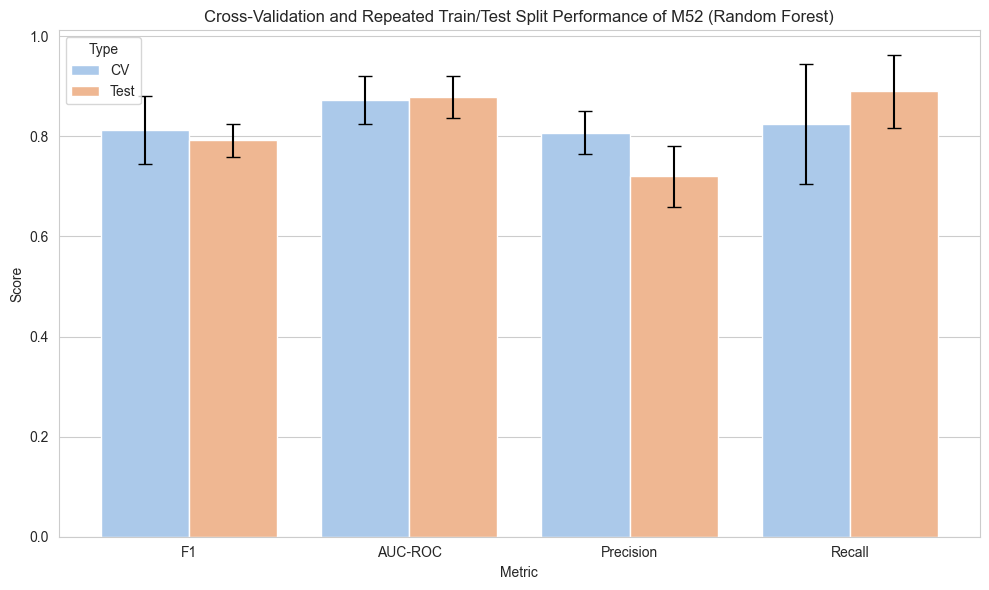

In [61]:
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

# Set a more aesthetic style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

metric_cols = ['F1', 'AUC-ROC', 'Precision', 'Recall']

cv_df = pd.DataFrame(cv_metrics)[['f1', 'auc_roc', 'precision', 'recall']]

cv_means = cv_df.mean()
cv_stds = cv_df.std()

# Test means and stds from the repeated train/test splits (cell 23)
test_means = pd.Series({
    'F1': mean_f1,
    'AUC-ROC': mean_auc,
    'Precision': mean_precision,
    'Recall': mean_recall
})

test_stds = pd.Series({
    'F1': std_f1,
    'AUC-ROC': std_auc,
    'Precision': std_precision,
    'Recall': std_recall
})

# Prepare data for seaborn

data = []
for metric in metric_cols:
    data.append({'Metric': metric, 'Mean': cv_means[metric.lower().replace('-', '_')], 'Std': cv_stds[metric.lower().replace('-', '_')], 'Type': 'CV'})
    data.append({'Metric': metric, 'Mean': test_means[metric], 'Std': test_stds[metric], 'Type': 'Test'})

df_plot = pd.DataFrame(data)

# Create the bar plot with error bars using seaborn
ax = sns.barplot(data=df_plot, x='Metric', y='Mean', hue='Type', ci=None, palette='pastel')
ax.errorbar(x=[i - 0.2 for i in range(len(metric_cols))], y=cv_means, yerr=cv_stds, fmt='none', c='black', capsize=5)
ax.errorbar(x=[i + 0.2 for i in range(len(metric_cols))], y=test_means, yerr=test_stds, fmt='none', c='black', capsize=5)

ax.set_ylabel('Score')
ax.set_title('Cross-Validation and Repeated Train/Test Split Performance of M52 (Random Forest)')
ax.legend(title='Type')

plt.tight_layout()
plt.show()


In [60]:
# extract results as a table 
results_table = df_plot.pivot(index='Metric', columns='Type', values=['Mean', 'Std'])
results_table.columns = ['_'.join(col).strip() for col in results_table.columns.values
]
results_table = results_table.reset_index()
print(results_table)

      Metric   Mean_CV  Mean_Test    Std_CV  Std_Test
0    AUC-ROC  0.872521   0.878750  0.047269  0.041779
1         F1  0.812732   0.791729  0.067964  0.033412
2  Precision  0.807068   0.719810  0.043183  0.061505
3     Recall  0.825000   0.890000  0.120221  0.073485
